In [57]:
import pandas as pd
import openpyxl

## Union de tablas

In [58]:
df1=pd.read_excel('df_ordenado.xlsx')
df2=pd.read_csv("CLIMA.csv")


In [59]:
df1.head()

,CodigoArticulo,Unidades,FechaAlbaran
0,940-005,1,2021-01-04
1,940-525,1,2021-02-16
2,940-525,1,2021-02-19
3,940-515,1,2021-02-22
4,940-515,1,2021-02-23


In [60]:
df2.head()

,Unnamed: 0,datetime,temp,windgust,windspeed,conditions
0,0,2021-01-01,3.5,83.5,29.3,"Snow, Rain, Partially cloudy"
1,1,2021-01-02,1.9,56.5,23.2,Partially cloudy
2,2,2021-01-03,2.1,34.2,22.5,Partially cloudy
3,3,2021-01-04,2.5,28.1,19.4,Partially cloudy
4,4,2021-01-05,0.8,22.3,8.2,Clear


In [61]:
df3=df2.drop(columns=["Unnamed: 0"])
df3=df3.rename(columns={"datetime" : "fecha"})
df1=df1.rename(columns={"FechaAlbaran": "fecha"})

In [62]:
df3.shape

(1352, 5)

In [63]:
df3.dtypes

fecha          object
temp          float64
windgust      float64
windspeed     float64
conditions     object
dtype: object

In [64]:
df3["fecha"]=pd.to_datetime(df3["fecha"])

In [65]:
df1.shape

(243, 3)

In [66]:
df1.nunique()

CodigoArticulo     12
Unidades           11
fecha             175
dtype: int64

Se repiten fechas por eso nuestro merged tendra...78 mas que df3 es decir 1420

In [67]:
df_merged=pd.merge(df3,df1,how="left",on="fecha")
df_merged

,fecha,temp,windgust,windspeed,conditions,CodigoArticulo,Unidades
0,2021-01-01,3.5,83.5,29.3,"Snow, Rain, Partially cloudy",NaN,NaN
1,2021-01-02,1.9,56.5,23.2,Partially cloudy,NaN,NaN
2,2021-01-03,2.1,34.2,22.5,Partially cloudy,NaN,NaN
3,2021-01-04,2.5,28.1,19.4,Partially cloudy,940-005,1.0
4,2021-01-05,0.8,22.3,8.2,Clear,NaN,NaN
...,...,...,...,...,...,...,...
1415,2024-09-06,20.4,46.8,25.8,Partially cloudy,NaN,NaN
1416,2024-09-07,18.9,36.0,19.4,Partially cloudy,NaN,NaN
1417,2024-09-08,20.7,28.8,21.0,Clear,NaN,NaN
1418,2024-09-09,21.2,16.9,7.0,Clear,NaN,NaN


In [68]:
df_merged.isnull().sum()

fecha                0
temp                 0
windgust             0
windspeed            0
conditions           0
CodigoArticulo    1178
Unidades          1178
dtype: int64

Podríamos pensar en hacer un inner y quedarnos solo con los que tenemos datos, pero necesitamos el historico completo, por lo que relenaremos con cero la unidades de los dias que no hay datos

Veamos la serie temporal con unidades y tiempo y Hacemos el EDA de la serie temporal

## EDA serie 

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
sns.set(style='whitegrid')

In [70]:
df_merged.head()

,fecha,temp,windgust,windspeed,conditions,CodigoArticulo,Unidades
0,2021-01-01,3.5,83.5,29.3,"Snow, Rain, Partially cloudy",NaN,NaN
1,2021-01-02,1.9,56.5,23.2,Partially cloudy,NaN,NaN
2,2021-01-03,2.1,34.2,22.5,Partially cloudy,NaN,NaN
3,2021-01-04,2.5,28.1,19.4,Partially cloudy,940-005,1.0
4,2021-01-05,0.8,22.3,8.2,Clear,NaN,NaN


In [71]:
# Convertir a DataFrame con índice temporal

df = df_merged[["fecha","Unidades"]]
df.set_index("fecha", inplace=True)
df.head()

,Unidades
fecha,
2021-01-01,NaN
2021-01-02,NaN
2021-01-03,NaN
2021-01-04,1.0
2021-01-05,NaN


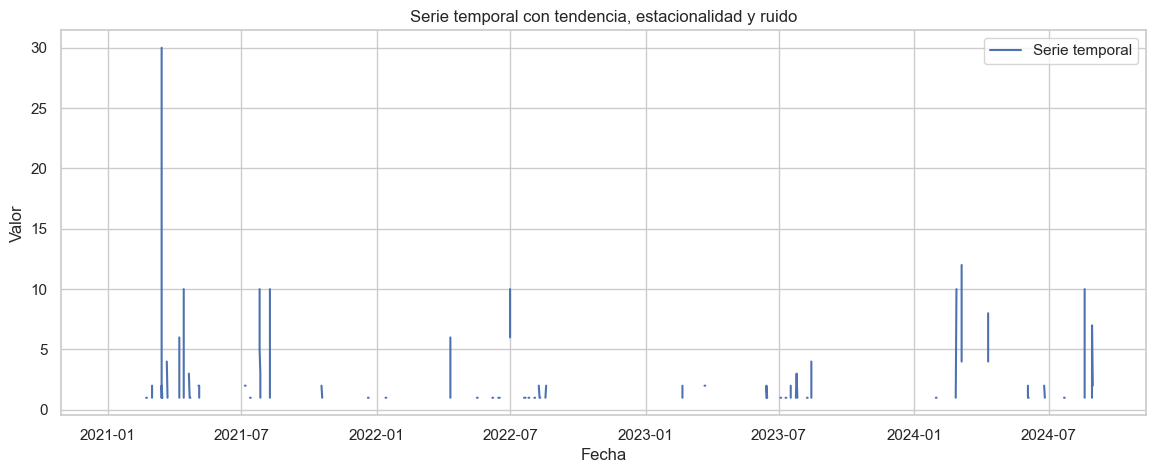

In [72]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Unidades'], label='Serie temporal')
plt.title("Serie temporal con tendencia, estacionalidad y ruido")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

In [73]:
import pandas as pd
import numpy as np
import plotly.express as px
# Gráfico interactivo
fig = px.line(df, x=df.index, y=df["Unidades"], title='Serie Temporal Interactiva')
fig.update_layout(
    xaxis_title='Fecha y Hora',
    yaxis_title='Valor',
    hovermode='x unified'
)
fig.show()

Nos fijamos que hay muchos valores nulos y como realmente estamos hablando de ventas de productos registradas por la propia empresa consideramos que es un dato lo suficientemente fiable como para con seguridad imputar cero en aquellos datos donde esta nulo

In [74]:
df["Unidades"]=df["Unidades"].fillna(0)
df["Unidades"]=df["Unidades"].astype(int)

C:\Users\jcasares\AppData\Local\Temp\ipykernel_21484\1456828843.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\jcasares\AppData\Local\Temp\ipykernel_21484\1456828843.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### Solo diario

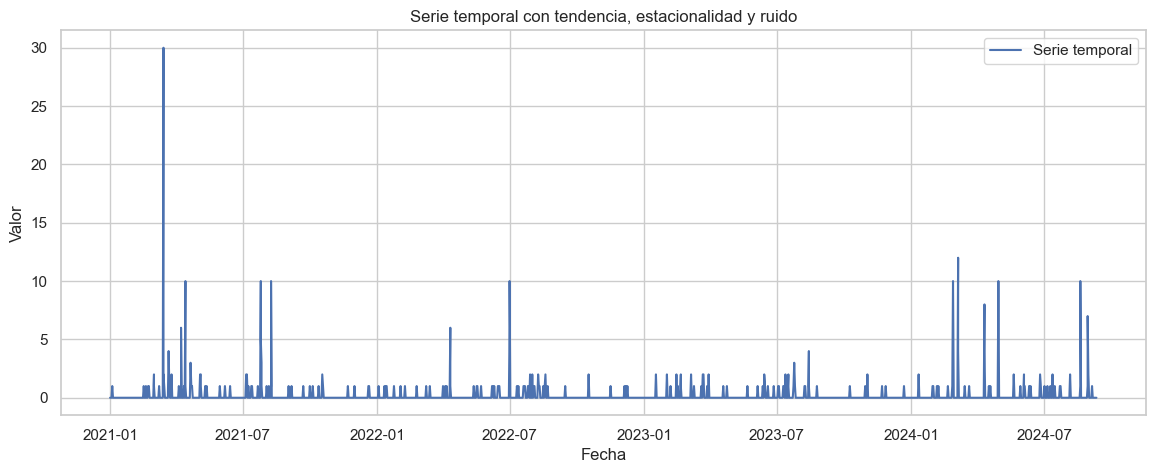

In [75]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Unidades'], label='Serie temporal')
plt.title("Serie temporal con tendencia, estacionalidad y ruido")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

Mejor vista..

In [76]:
import pandas as pd
import numpy as np
import plotly.express as px

# Gráfico interactivo
fig = px.line(df, x=df.index, y=df["Unidades"], title='Serie Temporal Interactiva')
fig.update_layout(
    xaxis_title='Fecha y Hora',
    yaxis_title='Valor',
    hovermode='x unified'
)
fig.show()

Hacemos agrupaciones por semanas y por meses y por año, que es basicamente lo que mas interes nos brinda a nosotros (simplemente por echarle un vistazo asi rapidillo)

In [77]:

# 2. 📊 Estadísticas descriptivas
print("📊 Estadísticas básicas:\n")
df['Unidades'].describe().reset_index()


📊 Estadísticas básicas:



,index,Unidades
0,count,1420.000000
1,mean,0.329577
2,std,1.369598
3,min,0.000000
4,25%,0.000000
5,50%,0.000000
6,75%,0.000000
7,max,30.000000


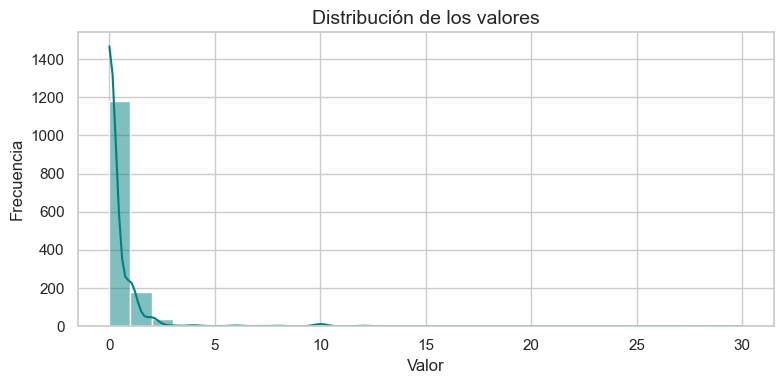

In [78]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Unidades'], bins=30, kde=True, color='teal')
plt.title("Distribución de los valores", fontsize=14)
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

no hace falta ver que tenemos un outlier.... asique el 30 unidades ese a ver que hacemos... podemos probar con dejarlo, suavizarlo o eliminarlo

Descomponemos la serie temporal, parece de primeras que tendencia apenas tiene, que estacionalidad si que tiene y que ruido muy poco... solo en los extremos (primer año y ultimoo). Vamos a comprobar esto, con el grafico de descomposición

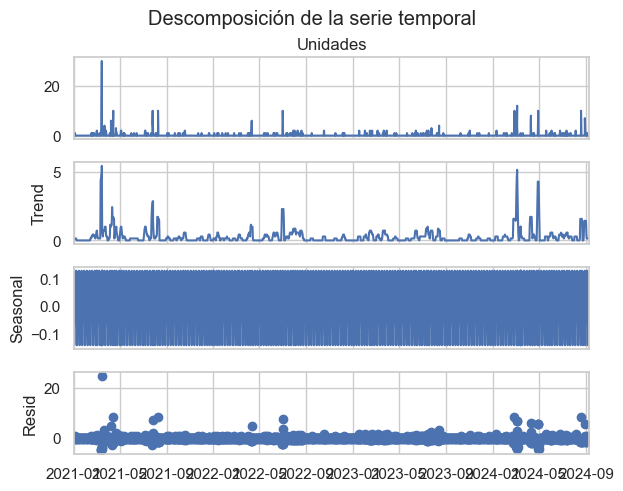

In [79]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns

descomp = seasonal_decompose(df['Unidades'], model='additive', period=7) #period=7 porque tenemos datos diarios
descomp.plot()
plt.suptitle("Descomposición de la serie temporal", y=1.02);

Parece que es super estacional, la tendencia parece que casi no hay y ruido apenas hay tambien, tenemos buenas condiciones... a priori

ACF y PACF

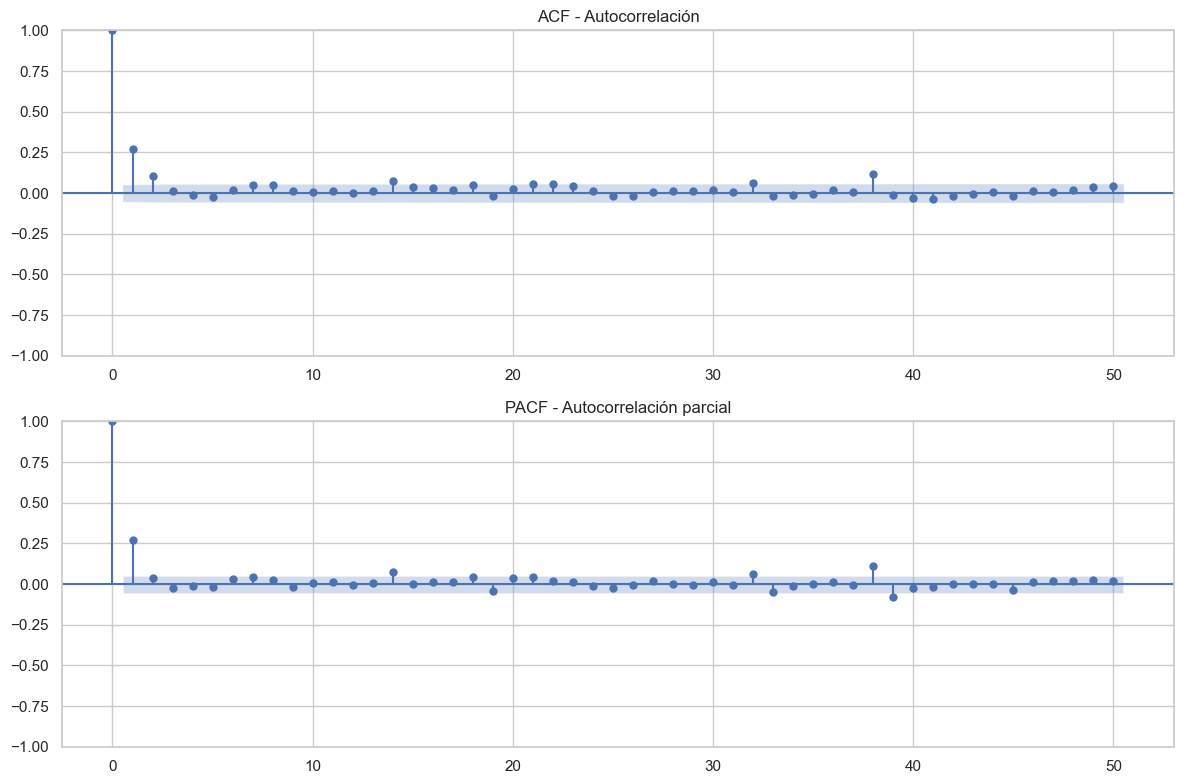

In [80]:

fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['Unidades'], lags=50, ax=ax[0])
plot_pacf(df['Unidades'], lags=50, ax=ax[1])
ax[0].set_title("ACF - Autocorrelación")
ax[1].set_title("PACF - Autocorrelación parcial")
plt.tight_layout()
plt.show()

AR(2), MA(2), I()... ARIMA(2,1,2) (PROBAR)

Test de estacionariedad:
H0: "la serie no es estacionaria"
HA: "la serie es estacionaria"

In [81]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller



# Aplicar el test de Dickey-Fuller aumentado
resultado = adfuller(df)

# Mostrar los resultados
print("Estadístico de prueba:", resultado[0])
print("p-valor:", resultado[1])
print("Valores críticos:", resultado[4])

# Interpretación, nivel de significacion de 5 por ciento
if resultado[1] < 0.05:
    print("Rechazamos la hipótesis nula, por lo tanto La serie es estacionaria")
else:
    print("No se puede rechazar la hipótesis nula por lo tanto La serie NO es estacionaria")

Estadístico de prueba: -28.58561293849522
p-valor: 0.0
Valores críticos: {'1%': np.float64(-3.434966750462565), '5%': np.float64(-2.8635789736973725), '10%': np.float64(-2.5678555388041384)}
Rechazamos la hipótesis nula, por lo tanto La serie es estacionaria


Conclusiones: serie con dudosa estacionalidad, en el grafico de descomposicion nos sale mucha estacionalidad debido a que hay muchos ceros y ese patron se repite constantemente... por lo tanto es confuso sin embargo despues en ACF no encontramos patrones repetidos... y deberia haberlos
la serie es estacionaria todo debido a que se agrupan basicamente en cero todos y mantiene la media en cero y la variabilidad parece muy constante tambien
tendencia es neutra (de ahi que sea estacionaria)
ruido apenas tenemos

Por dias basicamente tenemos una muy mala serie temporal todo esto debido a que hay muchos ceros en las unidades etc, etc probemos lo mismo pero de una serie agrupada por semana, lo que tiene logica puesto que vamos a predecir por semanas...

### diario semanal quincenal y mensual

In [82]:
df_semanal=df.resample("W").sum()
df_quincenal=df.resample("2W").sum()
df_mensual=df.resample("ME").sum()

In [83]:
df_semanal

,Unidades
fecha,
2021-01-03,0
2021-01-10,1
2021-01-17,0
2021-01-24,0
2021-01-31,0
...,...
2024-08-18,0
2024-08-25,11
2024-09-01,10


In [84]:
df_quincenal

,Unidades
fecha,
2021-01-03,0
2021-01-17,1
2021-01-31,0
2021-02-14,0
2021-02-28,4
...,...
2024-07-28,4
2024-08-11,2
2024-08-25,11


In [85]:
df_mensual.shape

(45, 1)

In [86]:
df_mensual

,Unidades
fecha,
2021-01-31,1
2021-02-28,4
2021-03-31,53
2021-04-30,27
2021-05-31,10
2021-06-30,2
2021-07-31,30
2021-08-31,13
2021-09-30,3


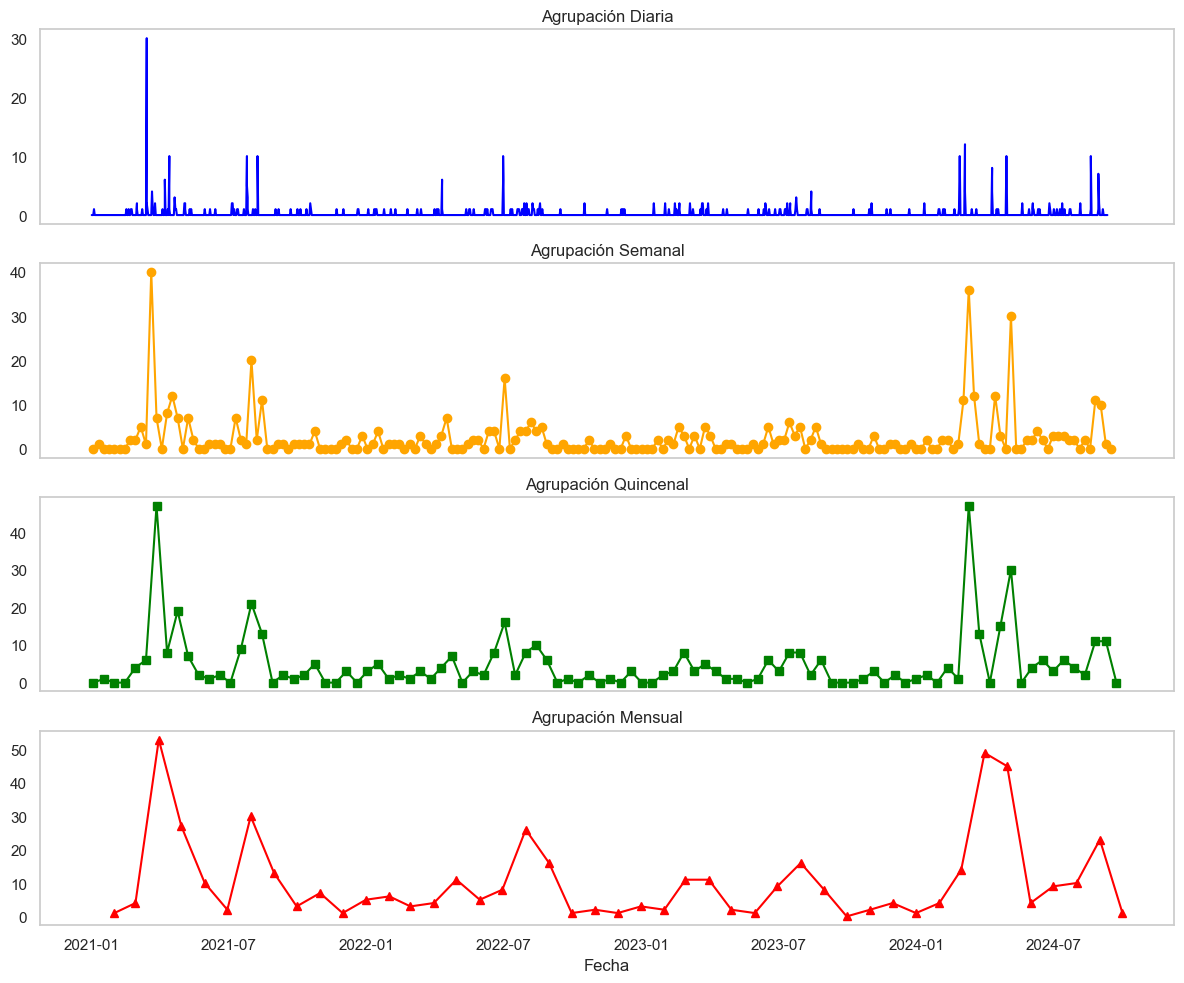

In [87]:
import pandas as pd
import matplotlib.pyplot as plt



# Crear subgráficas
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Graficar cada agrupación en un subplot
axes[0].plot(df.index, df, label="Diaria", color="blue")
axes[0].set_title("Agrupación Diaria")
axes[0].grid()

axes[1].plot(df_semanal.index, df_semanal, label="Semanal", color="orange", marker="o")
axes[1].set_title("Agrupación Semanal")
axes[1].grid()

axes[2].plot(df_quincenal.index, df_quincenal, label="Quincenal", color="green", marker="s")
axes[2].set_title("Agrupación Quincenal")
axes[2].grid()

axes[3].plot(df_mensual.index, df_mensual, label="Mensual", color="red", marker="^")
axes[3].set_title("Agrupación Mensual")
axes[3].grid()

# Ajustar diseño
plt.xlabel("Fecha")
fig.tight_layout()
plt.show()


In [88]:
import pandas as pd
import plotly.express as px



# Graficar interactivo
fig = px.line(df, x=df.index, y="Unidades", title="Serie Temporal Interactiva - Diaria")
fig.update_layout(xaxis_title="Fecha y Hora", yaxis_title="Valor", hovermode="x unified")
fig.show()

fig_semanal = px.line(df_semanal, x=df_semanal.index, y="Unidades", title="Serie Temporal Interactiva - Semanal")
fig_semanal.update_layout(xaxis_title="Fecha", yaxis_title="Valor", hovermode="x unified")
fig_semanal.show()

fig_quincenal = px.line(df_quincenal, x=df_quincenal.index, y="Unidades", title="Serie Temporal Interactiva - Quincenal")
fig_quincenal.update_layout(xaxis_title="Fecha", yaxis_title="Valor", hovermode="x unified")
fig_quincenal.show()

fig_mensual = px.line(df_mensual, x=df_mensual.index, y="Unidades", title="Serie Temporal Interactiva - Mensual")
fig_mensual.update_layout(xaxis_title="Fecha", yaxis_title="Valor", hovermode="x unified")
fig_mensual.show()

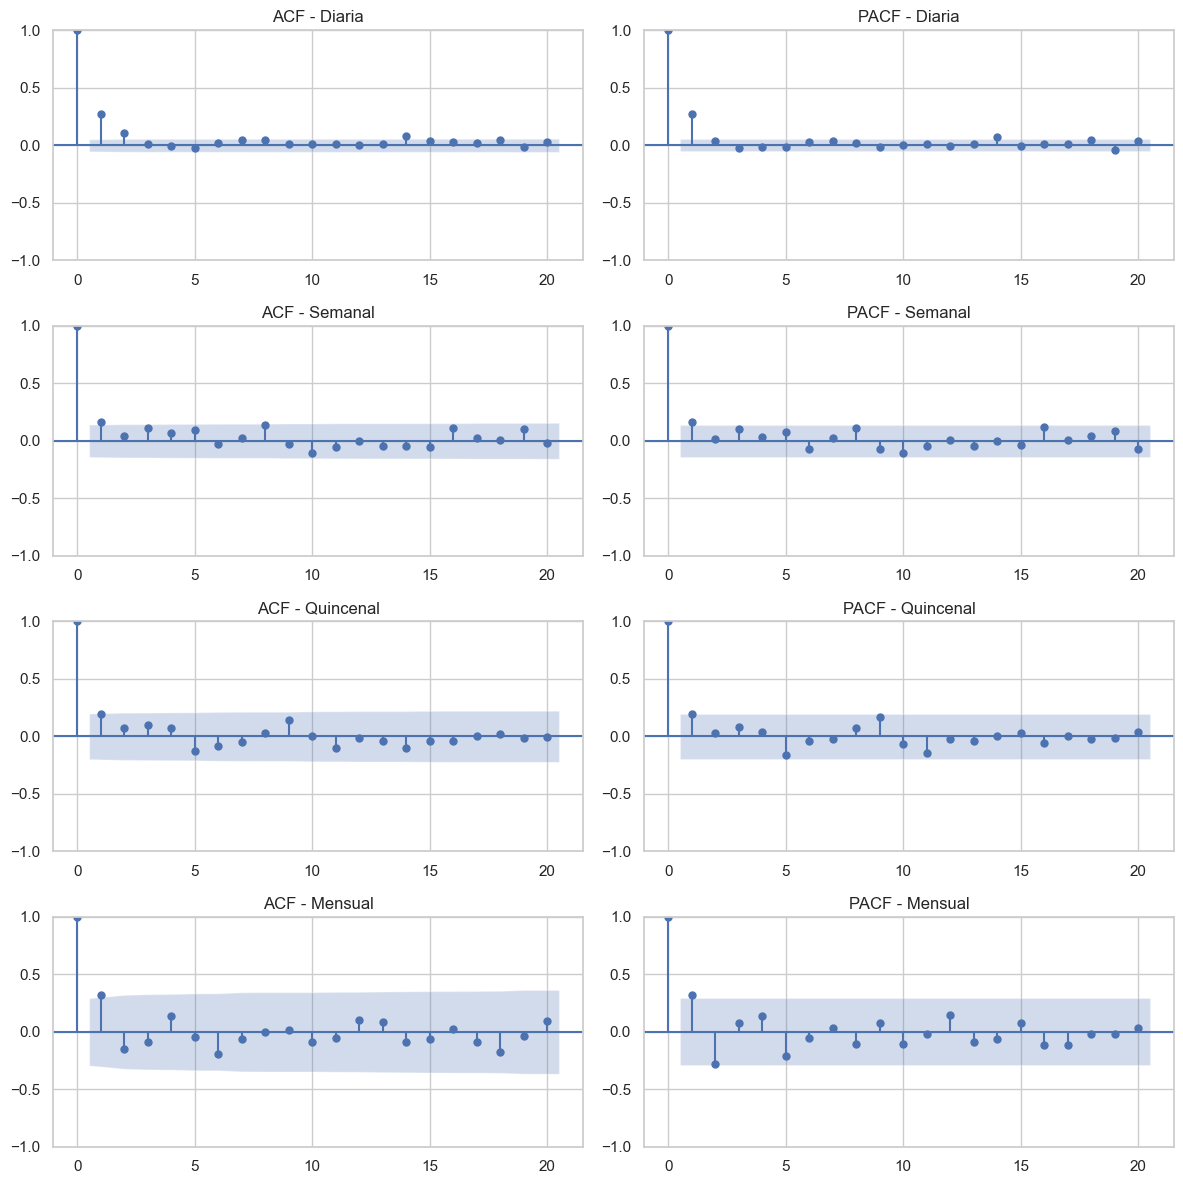

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Crear subgráficas para ACF y PACF de cada agrupación
fig, axes = plt.subplots(4, 2, figsize=(12, 12))

# Listas de DataFrames y títulos
datasets = [df, df_semanal, df_quincenal, df_mensual]
titulos = ["Diaria", "Semanal", "Quincenal", "Mensual"]

for i, data in enumerate(datasets):
    max_lags = min(len(data), 20)

    plot_acf(data["Unidades"], lags=max_lags, ax=axes[i, 0])
    plot_pacf(data["Unidades"], lags=max_lags, ax=axes[i, 1])
    axes[i, 0].set_title(f"ACF - {titulos[i]}")
    axes[i, 1].set_title(f"PACF - {titulos[i]}")

# Ajustar diseño
plt.tight_layout()
plt.show()

Vamos a interpretar esto realmente bien para entender porque he dicho antes que AR(2) MA(2) I(0) y esas cosas...
EXPLICAR MAÑANA COMO IDENTIFICAR LOS AR LOS MA Y PORQUE SE INCORPORA LA I...

La estacionalidad suele venir acompañada de basicamente 

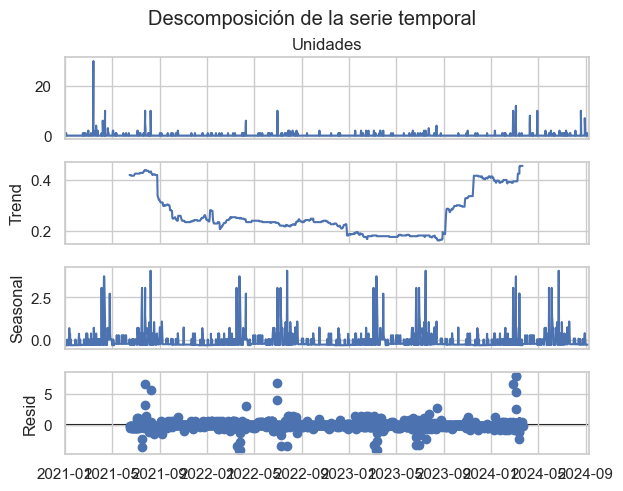

In [90]:
descomp = seasonal_decompose(df['Unidades'], model='additive', period=365)
descomp.plot()
plt.suptitle("Descomposición de la serie temporal", y=1.02);

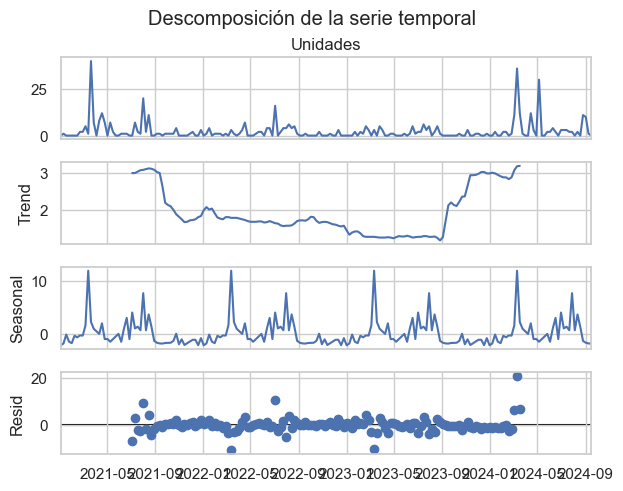

In [91]:
descomp = seasonal_decompose(df_semanal['Unidades'], model='additive', period=52)
descomp.plot()
plt.suptitle("Descomposición de la serie temporal", y=1.02);

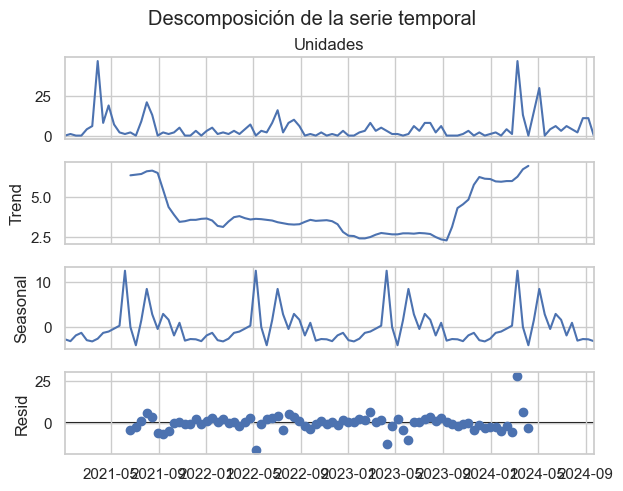

In [92]:
descomp = seasonal_decompose(df_quincenal['Unidades'], model='additive', period=24)
descomp.plot()
plt.suptitle("Descomposición de la serie temporal", y=1.02);

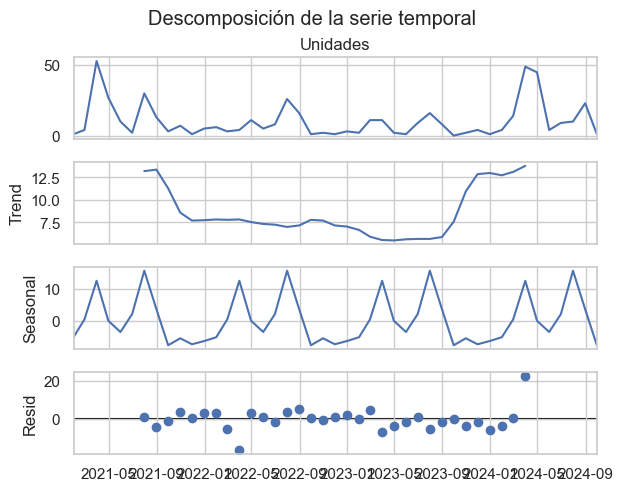

In [93]:
descomp = seasonal_decompose(df_mensual['Unidades'], model='additive', period=12)
descomp.plot()
plt.suptitle("Descomposición de la serie temporal", y=1.02);

In [94]:
from statsmodels.tsa.stattools import adfuller

# Aplicar el test de Dickey-Fuller
resultado_adf = adfuller(df_semanal["Unidades"])

# Mostrar resultados
print(f"Estadístico de prueba: {resultado_adf[0]}")
print(f"p-valor: {resultado_adf[1]}")
print(f"Valores críticos: {resultado_adf[4]}")

if resultado_adf[1] < 0.01:
    print("Rechazamos la hipótesis nula: La serie es estacionaria.")
else:
    print("No se puede rechazar la hipótesis nula: La serie NO es estacionaria.")

Estadístico de prueba: -11.735668912980062
p-valor: 1.3095887877085087e-21
Valores críticos: {'1%': np.float64(-3.4646940755442612), '5%': np.float64(-2.8766348847254934), '10%': np.float64(-2.5748163958763994)}
Rechazamos la hipótesis nula: La serie es estacionaria.


In [95]:
from statsmodels.tsa.stattools import adfuller

# Aplicar el test de Dickey-Fuller
resultado_adf = adfuller(df_quincenal["Unidades"])

# Mostrar resultados
print(f"Estadístico de prueba: {resultado_adf[0]}")
print(f"p-valor: {resultado_adf[1]}")
print(f"Valores críticos: {resultado_adf[4]}")

if resultado_adf[1] < 0.05:
    print("Rechazamos la hipótesis nula: La serie es estacionaria.")
else:
    print("No se puede rechazar la hipótesis nula: La serie NO es estacionaria.")

Estadístico de prueba: -4.656658096234274
p-valor: 0.00010142805833127506
Valores críticos: {'1%': np.float64(-3.5011373281819504), '5%': np.float64(-2.8924800524857854), '10%': np.float64(-2.5832749307479226)}
Rechazamos la hipótesis nula: La serie es estacionaria.


In [96]:
from statsmodels.tsa.stattools import adfuller

# Aplicar el test de Dickey-Fuller
resultado_adf = adfuller(df_mensual["Unidades"])

# Mostrar resultados
print(f"Estadístico de prueba: {resultado_adf[0]}")
print(f"p-valor: {resultado_adf[1]}")
print(f"Valores críticos: {resultado_adf[4]}")

if resultado_adf[1] < 0.01:
    print("Rechazamos la hipótesis nula: La serie es estacionaria.")
else:
    print("No se puede rechazar la hipótesis nula: La serie NO es estacionaria.")

Estadístico de prueba: -4.995041749527007
p-valor: 2.270010996438692e-05
Valores críticos: {'1%': np.float64(-3.5925042342183704), '5%': np.float64(-2.931549768951162), '10%': np.float64(-2.60406594375338)}
Rechazamos la hipótesis nula: La serie es estacionaria.


SARIMA!!!!!!!! PORQUE ES ESTACIONAL CONFIRMAMOS ROTUNDAMENTE... PROBAMOS ARIMA SARIMA Y PROPHET.... DIARIO NO Y PENSAR QUE SERIE DE LAS OTRAS TRES NOS VIENE MEJOR

## Elección

### Opcion quincenal

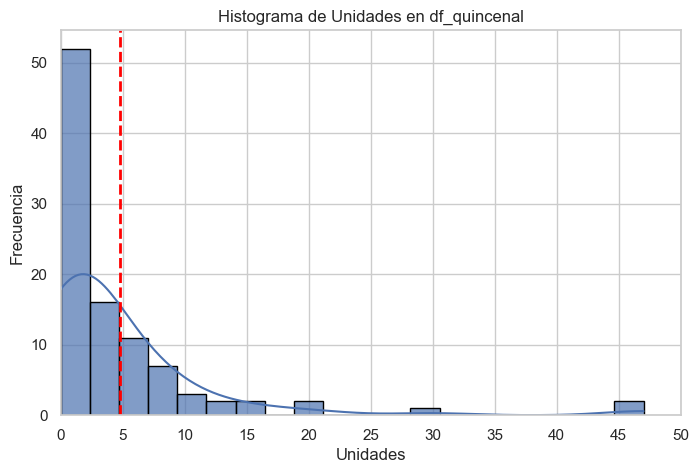

In [97]:
import matplotlib.pyplot as plt
import numpy as np

datos=df_quincenal["Unidades"]
media=np.mean(datos)

# Definir los límites del eje x
xmin = np.floor(min(datos) / 5) * 5  # Redondear hacia abajo al múltiplo de 5
xmax = np.ceil(max(datos) / 5) * 5  # Redondear hacia arriba al múltiplo de 5


# Crear el histograma
plt.figure(figsize=(8,5))
sns.histplot(datos, kde=True, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media')

# Agregar etiquetas
plt.xlabel("Unidades")
plt.xlim()
plt.ylabel("Frecuencia")
plt.title("Histograma de Unidades en df_quincenal")

plt.xlim(xmin, xmax)
plt.xticks(np.arange(xmin, xmax+1, 5))  # Intervalos de 5 en 5


# Mostrar gráfico
plt.show()

### Opcion mensual

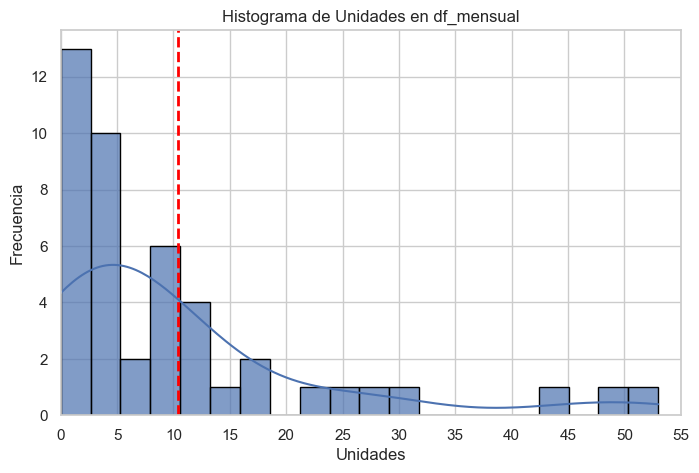

In [98]:
import matplotlib.pyplot as plt
import numpy as np

datos=df_mensual["Unidades"]
media=np.mean(datos)

# Definir los límites del eje x
xmin = np.floor(min(datos) / 5) * 5  # Redondear hacia abajo al múltiplo de 5
xmax = np.ceil(max(datos) / 5) * 5  # Redondear hacia arriba al múltiplo de 5


# Crear el histograma
plt.figure(figsize=(8,5))
sns.histplot(datos, kde=True, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media')

# Agregar etiquetas
plt.xlabel("Unidades")
plt.xlim()
plt.ylabel("Frecuencia")
plt.title("Histograma de Unidades en df_mensual")

plt.xlim(xmin, xmax)
plt.xticks(np.arange(xmin, xmax+1, 5))  # Intervalos de 5 en 5


# Mostrar gráfico
plt.show()

## Featuring engineering

In [99]:
df_merged

,fecha,temp,windgust,windspeed,conditions,CodigoArticulo,Unidades
0,2021-01-01,3.5,83.5,29.3,"Snow, Rain, Partially cloudy",NaN,NaN
1,2021-01-02,1.9,56.5,23.2,Partially cloudy,NaN,NaN
2,2021-01-03,2.1,34.2,22.5,Partially cloudy,NaN,NaN
3,2021-01-04,2.5,28.1,19.4,Partially cloudy,940-005,1.0
4,2021-01-05,0.8,22.3,8.2,Clear,NaN,NaN
...,...,...,...,...,...,...,...
1415,2024-09-06,20.4,46.8,25.8,Partially cloudy,NaN,NaN
1416,2024-09-07,18.9,36.0,19.4,Partially cloudy,NaN,NaN
1417,2024-09-08,20.7,28.8,21.0,Clear,NaN,NaN
1418,2024-09-09,21.2,16.9,7.0,Clear,NaN,NaN


In [100]:
df_encoded = pd.get_dummies(df_merged, columns=['conditions'])
df_encoded2= pd.get_dummies(df_encoded, columns=['CodigoArticulo'])
df_encoded2 = df_encoded2.applymap(lambda x: int(x) if isinstance(x, bool) else x) #Transformar todos los falses en 0 y los trues en 1
df_encoded2=df_encoded2.drop(columns=["windgust","windspeed"])
df_encoded2["fecha"] = pd.to_datetime(df_encoded2["fecha"])  # Convertir a datetime si no lo es
df_encoded2.set_index("fecha", inplace=True)  # Establecer la fecha como índice
df_encoded3=df_encoded2.resample("2W").agg(lambda x: x.mean() if x.name == "temp" else x.sum())
df_encoded3.dtypes

C:\Users\jcasares\AppData\Local\Temp\ipykernel_21484\2563083619.py:3: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



temp                                       float64
Unidades                                   float64
conditions_Clear                             int64
conditions_Overcast                          int64
conditions_Partially cloudy                  int64
conditions_Rain                              int64
conditions_Rain, Overcast                    int64
conditions_Rain, Partially cloudy            int64
conditions_Snow, Rain                        int64
conditions_Snow, Rain, Overcast              int64
conditions_Snow, Rain, Partially cloudy      int64
CodigoArticulo_940-001                       int64
CodigoArticulo_940-005                       int64
CodigoArticulo_940-010                       int64
CodigoArticulo_940-012                       int64
CodigoArticulo_940-015                       int64
CodigoArticulo_940-506                       int64
CodigoArticulo_940-508                       int64
CodigoArticulo_940-511                       int64
CodigoArticulo_940-515         

Vamos a usar el df diario para sacar la temperatura media, la acumulacion de series, y la acumulacion de productos

## One hot encoding

In [101]:
df_input=df_encoded3.resample("2W").sum()
df_input.dtypes

temp                                       float64
Unidades                                   float64
conditions_Clear                             int64
conditions_Overcast                          int64
conditions_Partially cloudy                  int64
conditions_Rain                              int64
conditions_Rain, Overcast                    int64
conditions_Rain, Partially cloudy            int64
conditions_Snow, Rain                        int64
conditions_Snow, Rain, Overcast              int64
conditions_Snow, Rain, Partially cloudy      int64
CodigoArticulo_940-001                       int64
CodigoArticulo_940-005                       int64
CodigoArticulo_940-010                       int64
CodigoArticulo_940-012                       int64
CodigoArticulo_940-015                       int64
CodigoArticulo_940-506                       int64
CodigoArticulo_940-508                       int64
CodigoArticulo_940-511                       int64
CodigoArticulo_940-515         

In [103]:
df_input["conditions_Snow"]=0
# Supongamos que ya tienes tu DataFrame df
columnas_clima = [col for col in df_input.columns if col.startswith("conditions_")]

# Mapeo de columnas combinadas para redistribuir los valores en clima
combinaciones_clima = {
    "conditions_Rain, Overcast": ["conditions_Rain", "conditions_Overcast"],
    "conditions_Rain, Partially cloudy": ["conditions_Rain", "conditions_Partially cloudy"],
    "conditions_Snow, Rain": ["conditions_Snow", "conditions_Rain"],
    "conditions_Snow, Rain, Overcast": ["conditions_Snow", "conditions_Rain", "conditions_Overcast"],
    "conditions_Snow, Rain, Partially cloudy":["conditions_Snow","conditions_Rain","conditions_Partially cloudy"]
}

# Asegurar que las columnas individuales existen en el DataFrame
for col in columnas_clima:
    if col not in df_input.columns:
        df_input[col] = 0  # Crear la columna si no existe

# Sumar los valores de las columnas combinadas a las individuales
for combinada, individuales in combinaciones_clima.items():
    if combinada in df_input.columns:  # Verificar que la columna combinada existe
        for col in individuales:
            df_input[col] += df_input[combinada]  # Sumar valores de la columna combinada
        df_input.drop(columns=[combinada], inplace=True)  # Eliminar columna combinada
df_input

,temp,Unidades,conditions_Clear,conditions_Overcast,conditions_Partially cloudy,conditions_Rain,CodigoArticulo_940-001,CodigoArticulo_940-005,CodigoArticulo_940-010,CodigoArticulo_940-012,CodigoArticulo_940-015,CodigoArticulo_940-506,CodigoArticulo_940-508,CodigoArticulo_940-511,CodigoArticulo_940-515,CodigoArticulo_940-520,CodigoArticulo_940-525,CodigoArticulo_R130101001,conditions_Snow
fecha,,,,,,,,,,,,,,,,,,,
2021-01-03,2.500000,0.0,0,0,3,1,0,0,0,0,0,0,0,0,0,0,0,0,1
2021-01-17,0.007143,1.0,6,2,5,5,0,1,0,0,0,0,0,0,0,0,0,0,5
2021-01-31,8.328571,0.0,1,3,10,10,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-02-14,9.614286,0.0,0,0,14,10,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-02-28,10.085714,4.0,1,0,13,2,0,0,0,0,0,0,0,0,2,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-28,28.526667,4.0,12,0,3,1,0,1,0,1,1,0,0,0,0,0,1,0,0
2024-08-11,30.292857,2.0,11,0,2,2,0,0,0,0,1,0,0,0,0,0,0,0,0
2024-08-25,27.633333,11.0,10,0,4,1,0,0,0,0,1,0,1,0,0,0,0,0,0


In [105]:
df_input["temp"] = df_input["temp"].round(2)  # Redondear a 2 decimales
df_input["Unidades"] = df_input["Unidades"].astype(int)  # Convertir a enteros
df_input


,temp,Unidades,conditions_Clear,conditions_Overcast,conditions_Partially cloudy,conditions_Rain,CodigoArticulo_940-001,CodigoArticulo_940-005,CodigoArticulo_940-010,CodigoArticulo_940-012,CodigoArticulo_940-015,CodigoArticulo_940-506,CodigoArticulo_940-508,CodigoArticulo_940-511,CodigoArticulo_940-515,CodigoArticulo_940-520,CodigoArticulo_940-525,CodigoArticulo_R130101001,conditions_Snow
fecha,,,,,,,,,,,,,,,,,,,
2021-01-03,2.50,0,0,0,3,1,0,0,0,0,0,0,0,0,0,0,0,0,1
2021-01-17,0.01,1,6,2,5,5,0,1,0,0,0,0,0,0,0,0,0,0,5
2021-01-31,8.33,0,1,3,10,10,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-02-14,9.61,0,0,0,14,10,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-02-28,10.09,4,1,0,13,2,0,0,0,0,0,0,0,0,2,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-28,28.53,4,12,0,3,1,0,1,0,1,1,0,0,0,0,0,1,0,0
2024-08-11,30.29,2,11,0,2,2,0,0,0,0,1,0,0,0,0,0,0,0,0
2024-08-25,27.63,11,10,0,4,1,0,0,0,0,1,0,1,0,0,0,0,0,0


In [106]:

df_input.to_csv("data_input.csv")



In [107]:
df_input.shape

(98, 19)